Initialize config.ini: Make specific path for each user

In [ ]:
%%writefile config.ini
[PATHS]
data_dir = /content/PlantTraits2024

Writing config.ini


In [ ]:
#Import Libraries
from google.colab import files
import pandas as pd
import csv
import numpy
import torch
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xg
import os

<h3> Go on kaggle account and download an API Token. It will download a .json file, which will uploaded in the following cell: <h3>

In [ ]:
!pip install --quiet kaggle

#Import kaggle.json
from google.colab import files
files.upload()   # select your kaggle.json here


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"yuanzougao","key":"532738968841fb805ef269db84221c75"}'}

Unzip file and create path to images

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3) Download & unzip the dataset in one go
!kaggle competitions download -c planttraits2024 -p /content
!mkdir -p /content/PlantTraits2024
!unzip -o -q /content/planttraits2024.zip -d /content/PlantTraits2024


In [ ]:
#Import data
uploaded, testdata, traindata = files.upload()

Saving sample_submission.csv to sample_submission.csv
Saving test.csv to test.csv
Saving train.csv to train.csv


In [ ]:
#Target Traits & Descriptions

filename = uploaded
with open(filename) as file:
    reader = csv.reader(file, delimiter='\t')
    for row in reader:
        print(row)

['id,X4,X11,X18,X50,X26,X3112']
['201238668,21.228749934658655,46.704746809507704,31.430122372477896,14.088638313859786,24.208951515736686,93.35105115771587']
['202310319,4.938497315907732,71.6444371507998,50.20840367473903,99.50344568755145,86.56112501725859,20.32573538565649']
['202604412,34.268158773824574,93.04648295740458,74.55694126555889,84.27574637261289,85.71329102448608,23.470287276377846']
['201353439,48.21387873798514,84.68777507949531,-1.4421583125162911,-9.852136731125029,13.327948589408532,-0.2747664033708457']
['195351745,55.1175010730814,87.04617216330053,84.33548320460179,79.21837649078236,19.142173955048573,11.294033221995772']


In [ ]:
#Create Dataframes

train = pd.read_csv(traindata)
test = pd.read_csv(testdata)

print('Training Rows:', train.shape[0])
print('Training Columns:', train.shape[1])
print('Testing Rows:', test.shape[0])
print('Testing Columns:', test.shape[1])

Training Rows: 55489
Training Columns: 176
Testing Rows: 6545
Testing Columns: 164


In [ ]:
from pathlib import Path
import pandas as pd

# ── 1) Base path ───────────────────────────────────────
base = Path('/content/PlantTraits2024')

# ── 2) Image folders ────────────────────────────────────────────────────────────
train_img_dir = base / 'train_images'
test_img_dir  = base / 'test_images'

# ── 3) Sanity checks ────────────────────────────────────────────────────────────
assert train_img_dir.exists(), f"{train_img_dir} not found!"
assert test_img_dir.exists(),  f"{test_img_dir} not found!"

# ── 4) Load metadata & targets ─────────────────────────────────────────────────
train = pd.read_csv(base / 'train.csv')
test  = pd.read_csv(base / 'test.csv')

# ── 5) Add img_path columns ─────────────────────────────────────────────────────
train['img_path'] = train['id'].apply(lambda x: str(train_img_dir / f"{x}.jpeg"))
test ['img_path'] = test ['id'].apply(lambda x: str(test_img_dir  / f"{x}.jpeg"))

# ── 6) Quick peek ───────────────────────────────────────────────────────────────
print(f"Train shape: {train.shape} | Test shape: {test.shape}")
train.head()


Train shape: (55489, 177) | Test shape: (6545, 165)


,id,WORLDCLIM_BIO1_annual_mean_temperature,WORLDCLIM_BIO12_annual_precipitation,WORLDCLIM_BIO13.BIO14_delta_precipitation_of_wettest_and_dryest_month,WORLDCLIM_BIO15_precipitation_seasonality,WORLDCLIM_BIO4_temperature_seasonality,WORLDCLIM_BIO7_temperature_annual_range,SOIL_bdod_0.5cm_mean_0.01_deg,SOIL_bdod_100.200cm_mean_0.01_deg,SOIL_bdod_15.30cm_mean_0.01_deg,...,X26_mean,X50_mean,X3112_mean,X4_sd,X11_sd,X18_sd,X26_sd,X50_sd,X3112_sd,img_path
0,192027691,12.235703,374.466675,62.524445,72.256844,773.592041,33.277779,125,149,136,...,1.243779,1.849375,50.216034,0.008921,1.601473,0.025441,0.153608,0.279610,15.045054,/content/PlantTraits2024/train_images/19202769...
1,195542235,17.270555,90.239998,10.351111,38.220940,859.193298,40.009777,124,144,138,...,0.642940,1.353468,574.098472,0.003102,0.258078,0.000866,0.034630,0.010165,11.004477,/content/PlantTraits2024/train_images/19554223...
2,196639184,14.254504,902.071411,49.642857,17.873655,387.977753,22.807142,107,133,119,...,0.395241,2.343153,1130.096731,NaN,NaN,NaN,NaN,NaN,NaN,/content/PlantTraits2024/train_images/19663918...
3,195728812,18.680834,1473.933350,163.100006,45.009758,381.053986,20.436666,120,131,125,...,0.154200,1.155308,1042.686546,0.011692,2.818356,0.110673,0.011334,0.229224,141.857187,/content/PlantTraits2024/train_images/19572881...
4,195251545,0.673204,530.088867,50.857777,38.230709,1323.526855,45.891998,91,146,120,...,10.919966,2.246226,2386.467180,0.006157,1.128000,0.026996,0.553815,0.107092,87.146899,/content/PlantTraits2024/train_images/19525154...


Text(0.5, 1.0, 'ID = 192027691')

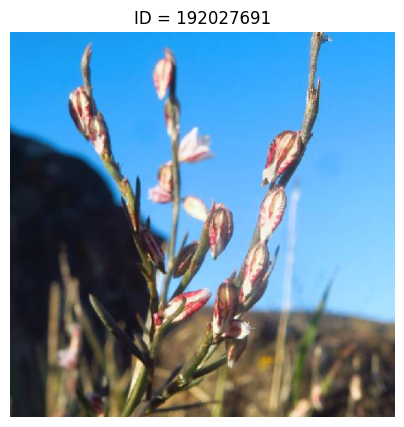

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

#Show exmaple image
sample_row = train.iloc[0]
img_path   = sample_row['img_path']
img = Image.open(img_path)
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis('off')
plt.title(f"ID = {sample_row['id']}")

=== Trait Summary ===
             count          mean           std       min         25%  \
X4_mean     5549.0      0.527194  1.607367e-01 -1.163134    0.416978   
X11_mean    5549.0     17.220403  5.023843e+01  0.001211   10.413297   
X18_mean    5549.0  49030.861966  3.652081e+06  0.000008    0.320878   
X26_mean    5549.0   5675.113265  4.170335e+05  0.000179    0.596549   
X50_mean    5549.0      1.770739  5.110457e+00  0.018173    1.172488   
X3112_mean  5549.0   3359.340003  4.743774e+04  0.006858  260.324583   

                   50%          75%           max  
X4_mean       0.515642     0.626661  2.428698e+00  
X11_mean     15.029456    19.566657  2.532092e+03  
X18_mean      0.712829     3.700473  2.720494e+08  
X26_mean      2.650551    15.098014  3.106555e+07  
X50_mean      1.478657     1.930171  2.734903e+02  
X3112_mean  715.379499  2106.815899  2.770958e+06  

=== Top 10 Columns by Missingness (%) ===
X18_sd                                    28.996216
X50_sd        

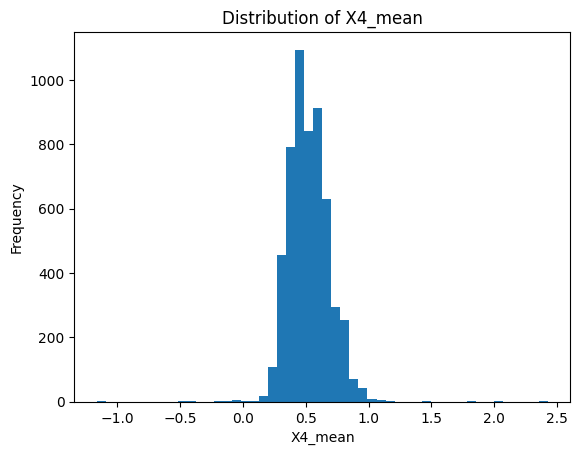

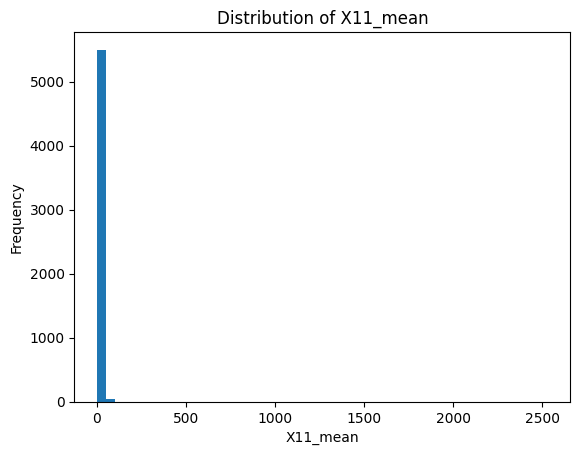

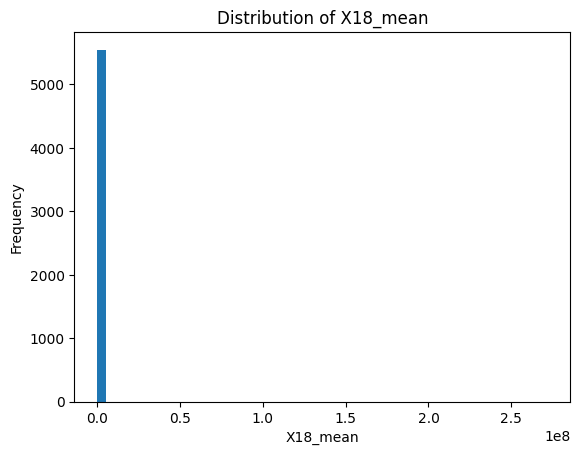

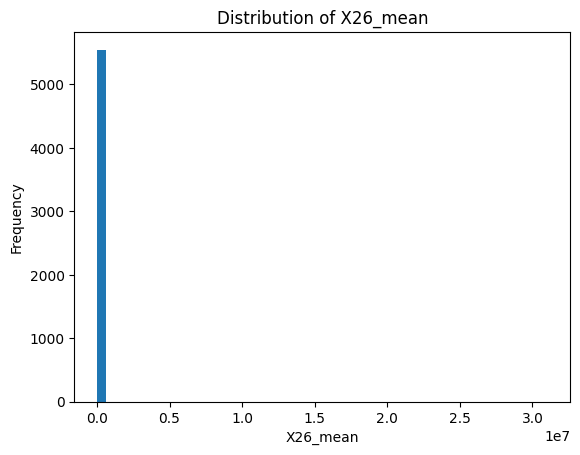

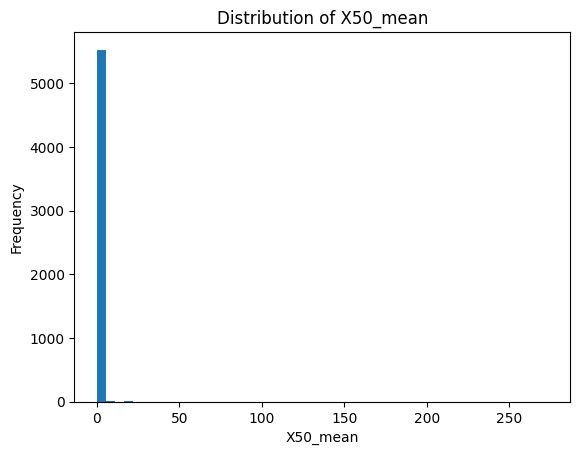

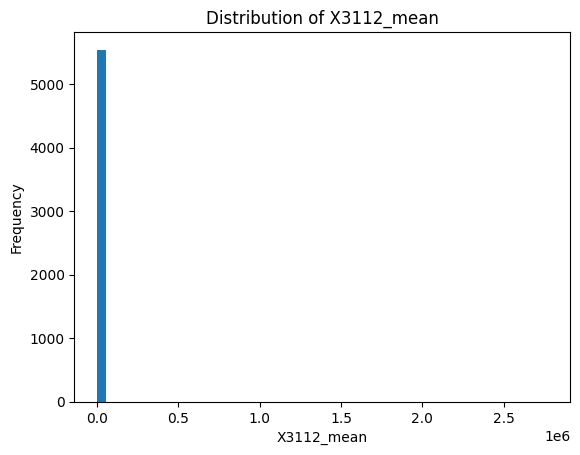

In [ ]:
import matplotlib.pyplot as plt

# 1) Identify the six continuous targets
# Optional: Accelerate debugging with a 10% training set
train = train.sample(frac=0.1, random_state=42).reset_index(drop=True)

target_cols = [c for c in train.columns if c.endswith('_mean')]

# 2) Summary statistics
print("=== Trait Summary ===")
print(train[target_cols].describe().T)

# 3) Percent missing per column (top 10 columns)
missing = (train.isna().sum() / len(train) * 100).sort_values(ascending=False)
print("\n=== Top 10 Columns by Missingness (%) ===")
print(missing.head(10))

# 4) Histograms for each trait
for trait in target_cols:
    plt.figure()
    plt.hist(train[trait].dropna(), bins=50)
    plt.title(f"Distribution of {trait}")
    plt.xlabel(trait)
    plt.ylabel("Frequency")
    plt.show()


In [ ]:
#PRE-PROCESSING BLOCK
# ── IMPORTS ─────────────────────────────────────────────────────────────────────
import torch
from torch.utils.data     import Dataset, DataLoader
from torchvision          import transforms
from PIL                  import Image
import numpy               as np
from sklearn.model_selection import train_test_split
from sklearn.impute       import SimpleImputer
from sklearn.preprocessing import StandardScaler
from scipy.stats          import zscore

# ── 1) Identify six continuous targets ─────────────────────────────────────
target_cols = [c for c in train.columns if c.endswith('_mean')]

# ── 2) Label-Outlier Removal (optional) ──────────────────────────────────────────
print(f"▶️  Train before label cleanup: {train.shape}")
pct = 99
thresholds = {col: np.percentile(train[col], pct) for col in target_cols}
for col, t in thresholds.items():
    train = train[train[col] < t]
print(f"▶️  Train after  {pct}th-pctile filter: {train.shape}")

# ── 3) Train/Val Split ───────────────────────────────────────────────────────────
train_df, val_df = train_test_split(train, test_size=0.20, random_state=42)

# ── 4) ResNet-50 Image Transforms ────────────────────────────────────────────────
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8,1.0), ratio=(3/4,4/3)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.1, scale=(0.02,0.2), ratio=(0.3,3.3), value='random'),
    transforms.Normalize(mean, std),
])
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# ── 5) Metadata Preprocessing for Fusion (optional) ─────────────────────────────
#    If we want to fuse. else skip.
metadata_cols = [col for col in train_df.columns if col not in target_cols + ['id', 'img_path']]

# 5a) Mean-impute
imp   = SimpleImputer(strategy='mean')
timp  = imp.fit_transform(train_df[metadata_cols])
vimp  = imp.transform(  val_df[metadata_cols])

# 5b) Drop any train row with metadata z-score > 3
zs    = np.abs(zscore(timp, axis=0))
keep  = (zs <= 3).all(axis=1)
train_df = train_df.loc[keep].reset_index(drop=True)
timp     = timp[keep]

# 5c) Standard-scale
scaler     = StandardScaler()
tmeta      = scaler.fit_transform(timp)
vmeta      = scaler.transform(vimp)

# 5d) Write back into DataFrames
train_df[metadata_cols] = tmeta
val_df  [metadata_cols] = vmeta

train_df[metadata_cols] = train_df[metadata_cols].astype(np.float32)
val_df[metadata_cols] = val_df[metadata_cols].astype(np.float32)

print(f"▶️  Metadata prep done: {len(train_df)} train / {len(val_df)} val rows")

# ── 6) PyTorch Dataset & DataLoaders ────────────────────────────────────────────
class PlantResNetDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = Image.open(row['img_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        y = torch.tensor([float(row[col]) for col in target_cols], dtype=torch.float32)
        m = torch.tensor([float(row[col]) for col in metadata_cols], dtype=torch.float32)
        return img, m, y

batch_size, num_workers = 8, 2
train_ds = PlantResNetDataset(train_df, transform=train_transforms)
val_ds   = PlantResNetDataset(val_df,   transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=True)

print(f"▶️  {len(train_ds)} train samples  |  {len(val_ds)} val samples")
print(f"▶️  {len(train_loader)} train batches | {len(val_loader)} val batches")

▶️  Train before label cleanup: (5549, 177)
▶️  Train after  99th-pctile filter: (5247, 177)
▶️  Metadata prep done: 2985 train / 1050 val rows
▶️  2985 train samples  |  1050 val samples
▶️  374 train batches | 132 val batches


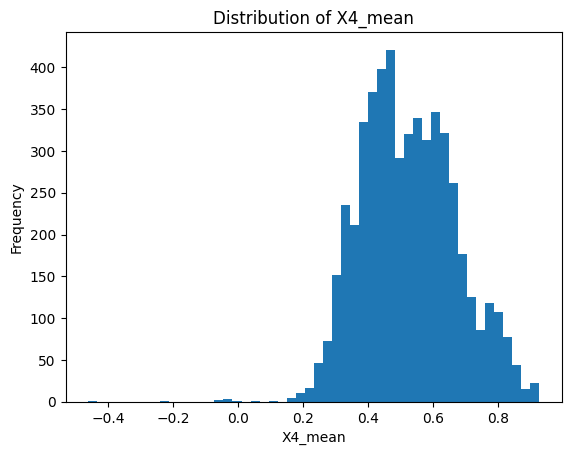

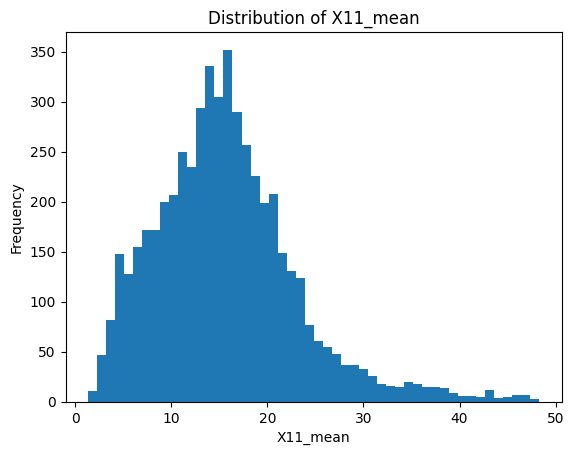

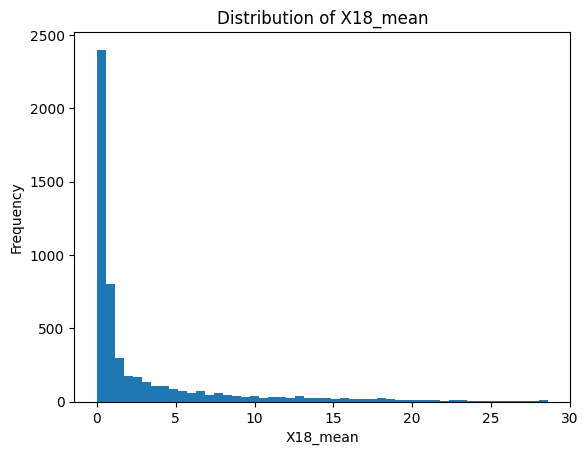

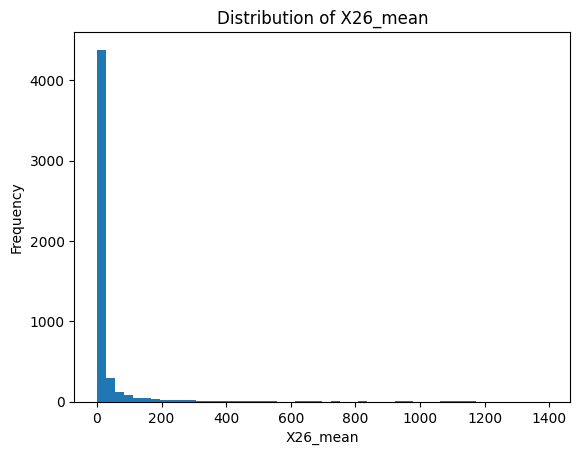

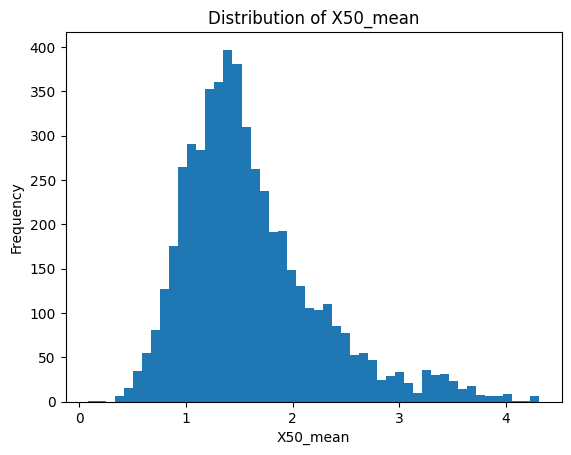

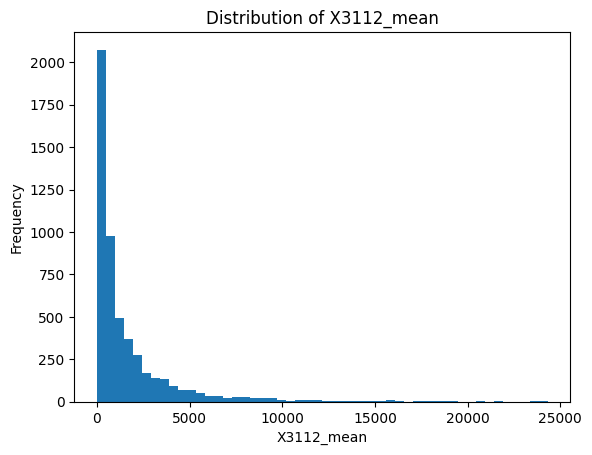

In [ ]:
#After dropping 1% of extreme target values
for trait in target_cols:
    plt.figure()
    plt.hist(train[trait].dropna(), bins=50)
    plt.title(f"Distribution of {trait}")
    plt.xlabel(trait)
    plt.ylabel("Frequency")
    plt.show()

## Model

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np

import torchvision

from torchvision import datasets, models, transforms

In [ ]:
class ResNet50WithMetadata(nn.Module):
  def __init__(self, meta_dim, num_classes=6):
    super(ResNet50WithMetadata, self).__init__()

    self.resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    self.resnet.fc = nn.Identity()

    self.meta_model = nn.Sequential(
      nn.Linear(meta_dim, 256),
      nn.ReLU(),
      nn.Linear(256, 64)
    )

    self.classifier = nn.Sequential(
        nn.Linear(2048 + 64, 256),
        nn.ReLU(),
        nn.Linear(256, num_classes)
    )
  def forward(self, image, metadata):
    image_features = self.resnet(image)
    meta_features = self.meta_model(metadata)

    combined = torch.cat([image_features, meta_features], dim=1)

    output = self.classifier(combined)  # (batch_size, num_classes)
    return output


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
print("len(metadata_cols):", len(metadata_cols))
print("metadata shape in training batch:", next(iter(train_loader))[1].shape[1])

len(metadata_cols): 169
metadata shape in training batch: 169


In [ ]:
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet50WithMetadata(meta_dim=len(metadata_cols), num_classes=6).to(device)

loss_fn = nn.L1Loss()
optimizer = optim.Adam(model.parameters())
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

batch_losses = []
train_epoch_losses = []
val_epoch_losses = []

n_epochs = 10

for epoch in range(n_epochs):
    model.train()

    running_loss = 0.0
    train_loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{n_epochs}]", leave=True)

    for images, metadata, labels in train_loop:
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        # Use loss_fn to calculate the loss
        outputs = model(images, metadata)
        loss = loss_fn(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update running loss
        running_loss += loss.item()
        batch_losses.append(loss.item())

        train_loop.set_postfix(loss=loss.item())

    train_epoch_loss = running_loss / len(train_loader)
    train_epoch_losses.append(train_epoch_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        val_loop = tqdm(val_loader, desc=f"Val Epoch [{epoch+1}/{n_epochs}]", leave=False)

        for val_images, val_metadata, val_labels in val_loop:
            val_images = val_images.to(device)
            val_metadata = val_metadata.to(device)
            val_labels = val_labels.to(device)

            val_outputs = model(val_images, val_metadata)
            val_loss = loss_fn(val_outputs, val_labels)

            running_val_loss += val_loss.item()
            val_loop.set_postfix(val_loss=val_loss.item())

    val_epoch_loss = running_val_loss / len(val_loader)
    val_epoch_losses.append(val_epoch_loss)
    print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {train_epoch_loss:.4f} | Val Loss: {val_epoch_loss:.4f}")

    scheduler.step()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 92.8MB/s]
Epoch [1/10]: 100%|██████████| 374/374 [33:18<00:00,  5.34s/it, loss=45.5]


Epoch 1/10 | Train Loss: 201.5570 | Val Loss: 203.5950


Epoch [2/10]: 100%|██████████| 374/374 [33:10<00:00,  5.32s/it, loss=62.4]


Epoch 2/10 | Train Loss: 177.0207 | Val Loss: 193.3255


Epoch [3/10]: 100%|██████████| 374/374 [33:42<00:00,  5.41s/it, loss=103]


...

Epoch 8/10 | Train Loss: 159.2766 | Val Loss: 200.3481


Epoch [9/10]: 100%|██████████| 374/374 [34:02<00:00,  5.46s/it, loss=76.7]


Epoch 9/10 | Train Loss: 158.3887 | Val Loss: 200.3499


Epoch [10/10]: 100%|██████████| 374/374 [33:59<00:00,  5.45s/it, loss=2.13e+3]
                                                                                   

Epoch 10/10 | Train Loss: 162.9482 | Val Loss: 203.1633


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for val_images, val_metadata, val_labels in val_loader:
        val_images = val_images.to(device)
        val_metadata = val_metadata.to(device)

        val_outputs = model(val_images, val_metadata).cpu().numpy()
        val_labels = val_labels.cpu().numpy()

        all_preds.append(val_outputs)
        all_labels.append(val_labels)

# join into a matrix
preds = np.vstack(all_preds)
labels = np.vstack(all_labels)

# Calculate R² and MAE for each trait separately
print("Per-trait evaluation:")
for i, col in enumerate(target_cols):
    r2 = r2_score(labels[:, i], preds[:, i])
    mae = mean_absolute_error(labels[:, i], preds[:, i])
    print(f"{col:15} | R²: {r2:.4f} | MAE: {mae:.4f}")

Per-trait evaluation:
X4_mean         | R²: -32.2311 | MAE: 0.4039
X11_mean        | R²: -0.0898 | MAE: 5.7133
X18_mean        | R²: -0.6373 | MAE: 3.1419
X26_mean        | R²: -0.0037 | MAE: 36.6938
X50_mean        | R²: -0.3618 | MAE: 0.5409
X3112_mean      | R²: 0.1306 | MAE: 1176.3218


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def compute_loss_metrics(loader, name='Set'):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, metadata, labels in loader:
            images = images.to(device)
            metadata = metadata.to(device)

            outputs = model(images, metadata).cpu().numpy()
            labels = labels.cpu().numpy()

            all_preds.append(outputs)
            all_labels.append(labels)

    preds = np.vstack(all_preds)
    labels = np.vstack(all_labels)

    l1 = mean_absolute_error(labels, preds)
    mse = mean_squared_error(labels, preds)

    print(f"{name} Evaluation:")
    print(f" - L1 Loss (MAE): {l1:.4f}")
    print(f" - MSE Loss: {mse:.4f}")
    return l1, mse

In [ ]:
# Compute MAE + MSE
train_l1, train_mse = compute_loss_metrics(train_loader, name='Train')
val_l1, val_mse = compute_loss_metrics(val_loader, name='Validation')

Train Evaluation:
 - L1 Loss (MAE): 158.3788
 - MSE Loss: 648540.1250
Validation Evaluation:
 - L1 Loss (MAE): 203.8025
 - MSE Loss: 1097735.8750


In [ ]:
from sklearn.metrics import r2_score
import numpy as np

def compute_r2(loader, name='Set'):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, metadata, labels in loader:
            images = images.to(device)
            metadata = metadata.to(device)

            outputs = model(images, metadata).cpu().numpy()
            labels = labels.cpu().numpy()

            all_preds.append(outputs)
            all_labels.append(labels)

    preds = np.vstack(all_preds)
    labels = np.vstack(all_labels)

    r2 = r2_score(labels, preds, multioutput='variance_weighted')

    print(f"{name} R² Score (weighted over all traits): {r2:.4f}")
    return r2

# -------- Train R² --------
train_r2 = compute_r2(train_loader, name='Train')

# -------- Validation R² --------
val_r2 = compute_r2(val_loader, name='Validation')

Train R² Score (weighted over all traits): 0.3189
Validation R² Score (weighted over all traits): 0.1303


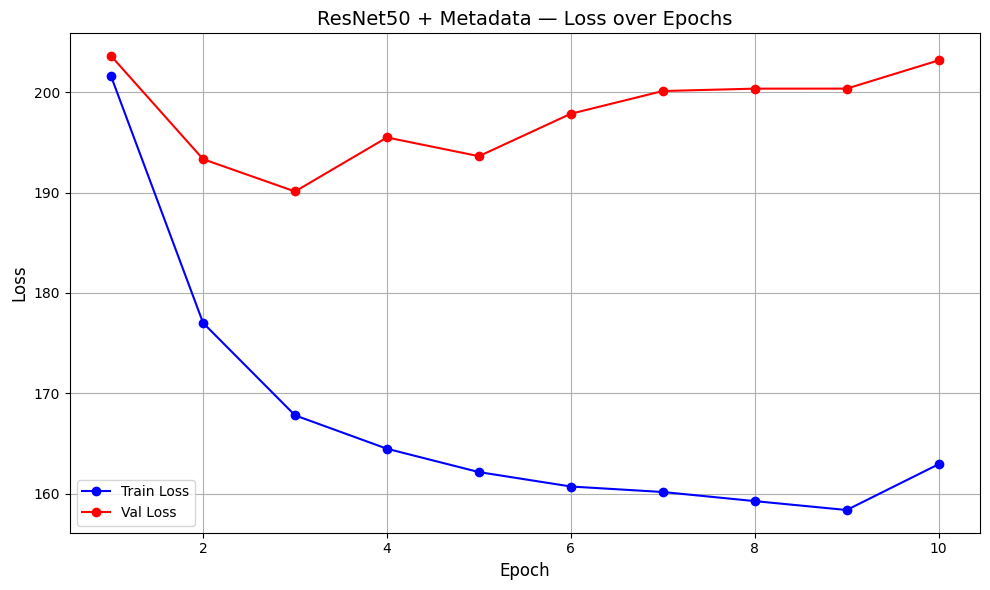

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_epoch_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_epoch_losses, 'bo-', label='Train Loss')  # blue
plt.plot(epochs, val_epoch_losses, 'ro-', label='Val Loss')      # red

plt.title('ResNet50 + Metadata — Loss over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Read the test.csv file
test = pd.read_csv(testdata)
print(f"Loaded test.csv: {len(test)} rows")

test['img_path'] = test['id'].apply(lambda x: str(test_img_dir / f"{x}.jpeg"))

✅ Loaded test.csv: 6545 rows


In [ ]:
# Check if there are any missing metadata columns, if so, fill them in
missing_cols = [col for col in metadata_cols if col not in test.columns]
for col in missing_cols:
    print(f"Adding missing column: {col}")
    test[col] = 0

Adding missing column: X4_sd
Adding missing column: X11_sd
Adding missing column: X18_sd
Adding missing column: X26_sd
Adding missing column: X50_sd
Adding missing column: X3112_sd


In [ ]:
# Process test metadata with previously trained imp and scaler
test_meta_imp = imp.transform(test[metadata_cols])
test_meta_sc = scaler.transform(test_meta_imp)
test[metadata_cols] = test_meta_sc.astype(np.float32)

print("✅ Test metadata preprocessing completed!")

✅ Test metadata preprocessing completed!


In [ ]:
# Define the Dataset class
class PlantResNetTestDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['img_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        metadata = torch.tensor([float(row[col]) for col in metadata_cols], dtype=torch.float32)
        return img, metadata

# Create Dataset & DataLoader
test_ds = PlantResNetTestDataset(test, transform=val_transforms)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print(f"✅ Test dataset ready: {len(test_ds)} samples, {len(test_loader)} batches")

✅ Test dataset ready: 6545 samples, 205 batches


In [ ]:
# Start forecasting
model.eval()
all_preds = []

with torch.no_grad():
    for images, metadata in tqdm(test_loader, desc="Predicting"):
        images = images.to(device)
        metadata = metadata.to(device)
        outputs = model(images, metadata).cpu().numpy()
        all_preds.append(outputs)

# Merge all batch results
final_preds = np.vstack(all_preds)
print(f"✅ Prediction completed. Shape: {final_preds.shape}")

Predicting: 100%|██████████| 205/205 [25:56<00:00,  7.59s/it]

✅ Prediction completed. Shape: (6545, 6)


In [ ]:
# Create a new commit file with the id and target columns
submission = pd.DataFrame({
    'id': test['id'],
    'X4_mean': final_preds[:, 0],
    'X11_mean': final_preds[:, 1],
    'X18_mean': final_preds[:, 2],
    'X26_mean': final_preds[:, 3],
    'X50_mean': final_preds[:, 4],
    'X3112_mean': final_preds[:, 5],
})

In [ ]:
submission.to_csv("my_new_submission.csv", index=False)
print("✅ Submission file saved: my_new_submission.csv")

✅ Submission file saved: my_new_submission.csv
